In [6]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

df = pd.read_parquet('Data/filtered_df.parquet')

# Restrict to nuclear transcripts
nuc = df[(df.cell_id != 'UNASSIGNED') & (df.overlaps_nucleus==1)]

# Discard tiny nuclei <5 transcripts
counts = nuc.groupby('cell_id').size()
good = counts[counts>=5].index
nuc = nuc[nuc['cell_id'].isin(good)]

In [7]:
nuc.head()

,x,y,z,feature_name,cell_id,codeword_index,transcript_id,nucleus_distance,qv,fov_name,codeword_category,is_gene,overlaps_nucleus
206,249.906250,2146.750000,22.187500,CEMIP,ffpiellh-1,278,281801394275084,0.0,40.00,X2,predesigned_gene,True,1
234,249.828125,2146.984375,24.578125,CHI3L1,ffpiellh-1,461,281801394242757,0.0,29.25,X2,custom_gene,True,1
333,249.953125,2147.343750,21.812500,HMOX1,ffpiellh-1,442,281801394290742,0.0,29.50,X2,custom_gene,True,1
517,249.656250,2147.437500,23.171875,STAB1,ffpiellh-1,453,281801394230261,0.0,28.50,X2,custom_gene,True,1
519,249.921875,2148.468750,24.500000,STAB1,ffpiellh-1,453,281801394234298,0.0,40.00,X2,custom_gene,True,1


In [94]:
# Normalize & log‑transform per nucleus
cell_gene_matrix = pd.crosstab(nuc['cell_id'], nuc['feature_name'])
ad = sc.AnnData(X=cell_gene_matrix)
ad.obs_names = cell_gene_matrix.index.astype(str)
ad.var_names = cell_gene_matrix.columns.astype(str)

In [ ]:
sc.pp.normalize_total(ad, target_sum=1e4)
sc.pp.log1p(ad)
sc.tl.pca(ad, svd_solver='arpack')
sc.pp.neighbors(ad, 
                n_neighbors=15, 
                n_pcs=50, 
                random_state=42)
sc.tl.leiden(ad, 
             resolution=0.5, 
             random_state=42)

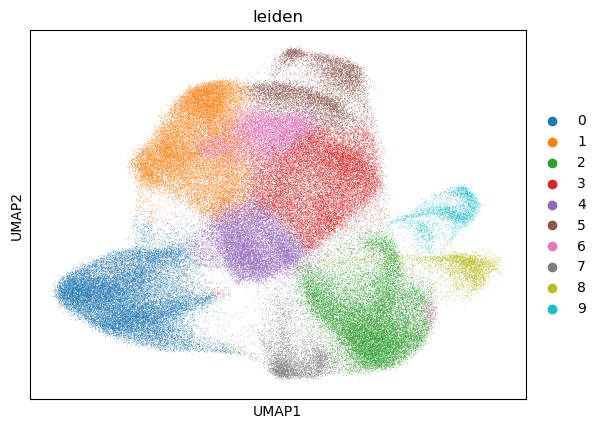

In [135]:
sc.tl.umap(ad)
sc.pl.umap(ad, color=['leiden'], save="_leiden_clusters.png")

In [101]:
# Compute per‑gene DE per cluster:
sc.tl.rank_genes_groups(ad, groupby='leiden', method='t-test')

/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_97408/3404617680.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = expr_df.groupby('cluster').mean().T


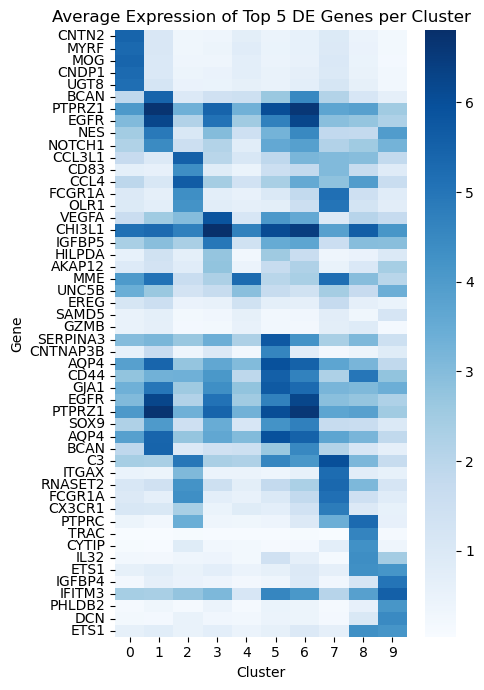

In [133]:
###########
# Heatmap #
###########
# Extract top 5 genes per cluster
de = ad.uns['rank_genes_groups']
clusters = sorted(ad.obs['leiden'].unique().tolist(), key=int)  # sort clusters numerically
cluster_top_genes = {}

for cluster in clusters:
    top_genes = list(pd.DataFrame(de['names'])[cluster].head(5).values)
    cluster_top_genes[cluster] = top_genes

# Flatten and remove dups
seen = set()
ordered_genes = []
for cluster in clusters:
    for g in cluster_top_genes[cluster]:
        if g not in seen:
            ordered_genes.append(g)
            seen.add(g)

# Get expression matrix 
expr_df = ad[:, ordered_genes].to_df()
expr_df['cluster'] = ad.obs['leiden'].values
heatmap_data = expr_df.groupby('cluster').mean().T

row_order = []
for cluster in clusters:
    for g in cluster_top_genes[cluster]:
        if g in heatmap_data.index:
            row_order.append(g)

heatmap_data = heatmap_data.loc[row_order, sorted(heatmap_data.columns, key=int)]

# Plot 
plt.figure(figsize=(5, 7))
sns.heatmap(heatmap_data, cmap="Blues", xticklabels=True, yticklabels=True)
plt.title("Average Expression of Top 5 DE Genes per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Gene")
plt.tight_layout()
plt.savefig("Plot/top5_gene_heatmap.png", dpi=600, bbox_inches='tight')
plt.show()

In [137]:
clusters = sorted(ad.obs['leiden'].unique().tolist())
n_clusters = len(clusters)
genes = ad.var_names.tolist()

# Access DE results
de = ad.uns['rank_genes_groups']
de_genes = pd.DataFrame(de['names'])           # shape: top_n × clusters
de_logfc = pd.DataFrame(de['logfoldchanges'])  # same shape
de_pvals = pd.DataFrame(de['pvals'])           # same shape

# Build embedding dictionary
gene_embedding_dict = defaultdict(lambda: [0.0] * (2 * n_clusters))  # zero-init for missing genes

for i, cluster in enumerate(clusters):
    for gene, lfc, p in zip(de_genes[cluster], de_logfc[cluster], de_pvals[cluster]):
        idx = i * 2
        gene_embedding_dict[gene][idx] = lfc
        gene_embedding_dict[gene][idx + 1] = -np.log10(max(p, 1e-10))  # avoid log(0)

gene_embedding_dict = dict(gene_embedding_dict)

In [147]:
import torch

tensor_dict = {gene: torch.tensor(emb, dtype=torch.float32) for gene, emb in gene_embedding_dict.items()}
torch.save(tensor_dict, "Data/gene_embedding_dict.pt")

In [157]:
from scipy.sparse import coo_matrix
from sklearn.cluster import AgglomerativeClustering
from shapely.geometry import MultiPoint
from scipy.spatial import Delaunay
from collections import Counter

df = pd.read_parquet('Data/filtered_df2.parquet')
coords = df[['x','y']].to_numpy()
n = coords.shape[0]

# Filter coords_roi 
xlim = (4100, 4150)
ylim = (1620, 1670)
def in_region(pt):
    return xlim[0] <= pt[0] <= xlim[1] and ylim[0] <= pt[1] <= ylim[1]
#
roi_mask   = np.array([in_region(p) for p in coords])
roi_indices = np.where(roi_mask)[0] 
coords_roi = coords[roi_mask]
n_roi      = len(coords_roi)
gene_names_roi = df.iloc[roi_indices]['feature_name'].values  

tri = Delaunay(coords_roi)
edges = {
    (min(tri_idx[i], tri_idx[j]), max(tri_idx[i], tri_idx[j]))
    for tri_idx in tri.simplices
    for i, j in [(0, 1), (1, 2), (2, 0)]
}
edges_df = pd.DataFrame(list(edges), columns=['i', 'j'])
edges_df['distance'] = edges_df.apply(
    lambda row: np.linalg.norm(coords_roi[row['i']] - coords_roi[row['j']]), axis=1
)
distance_threshold = 1.0  # µm
filtered_edges_df = edges_df[edges_df['distance'] <= distance_threshold].copy()

features = np.array([
    gene_embedding_dict.get(g, np.zeros(20))  
    for g in gene_names_roi
])

In [161]:
from sklearn.metrics.pairwise import cosine_similarity

row = filtered_edges_df['i'].to_numpy()
col = filtered_edges_df['j'].to_numpy()

# Compute cosine similarity per edge
sim = np.array([
    cosine_similarity(features[i].reshape(1, -1), features[j].reshape(1, -1))[0, 0]
    for i, j in zip(row, col)
])

In [163]:
conn_feat = coo_matrix((sim, (row, col)), shape=(n_roi, n_roi))
conn_feat = conn_feat + conn_feat.T  # symmetrize

agg = AgglomerativeClustering(
    n_clusters=24,
    linkage="average",
    connectivity=conn_feat
)
labels_agg_feat = agg.fit_predict(coords_roi)

/Users/lyuan13/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_agglomerative.py:596: UserWarning: the number of connected components of the connectivity matrix is 59 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


In [167]:
from sklearn.cluster import SpectralClustering

affinity = cosine_similarity(features)
affinity[affinity < 0.3] = 0.0
np.fill_diagonal(affinity, 1.0)  # ensure self-loops

#
sc = SpectralClustering(
    n_clusters=24,
    affinity='precomputed',
    assign_labels='discretize',
    eigen_solver='arpack',
    n_init=10,
    random_state=0
)
labels_spec_feat = sc.fit_predict(affinity)

In [170]:
import networkx as nx
import community.community_louvain as community_louvain

G = nx.Graph()
G.add_nodes_from(range(n_roi))
edges = [(i, j, float(s)) for i, j, s in zip(row, col, sim)]
G.add_weighted_edges_from(edges)

# 
partition = community_louvain.best_partition(G, resolution=0.1, weight='weight')
labels_louvain_feat = np.array([partition[i] for i in range(n_roi)])

/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_97408/2891057239.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)


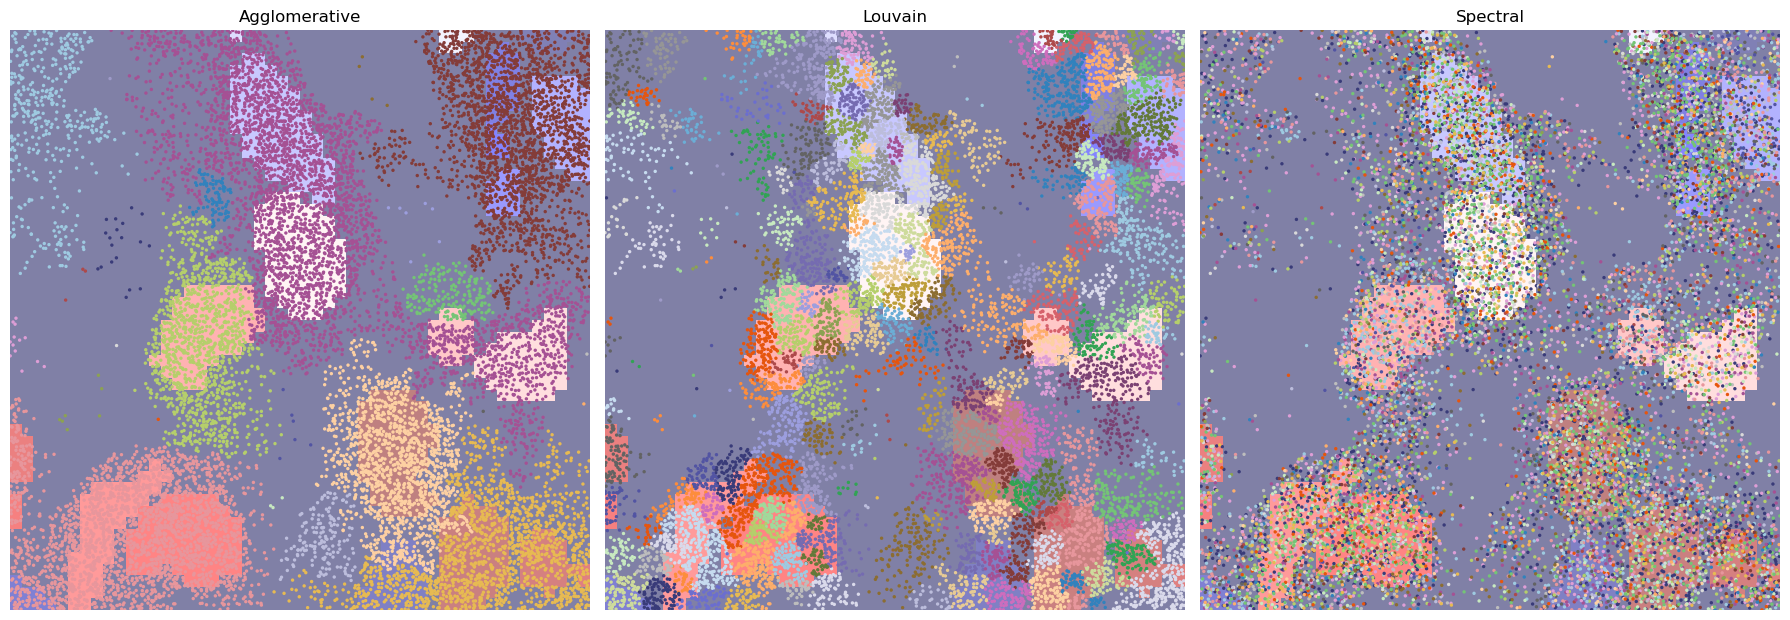

In [173]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

palette = list(cm.get_cmap("tab20b").colors) + list(cm.get_cmap("tab20c").colors)  
custom_cmap = ListedColormap(palette)

mask = np.load("Data/cell_nuc_masks/nucleus_mask_small.npy")

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

for ax, labels, title in zip(
    axes,
    [labels_agg_feat, labels_louvain_feat, labels_spec_feat],
    ["Agglomerative", "Louvain", "Spectral"]
):
    # Plot transcripts colored by cluster
    ax.scatter(
        coords_roi[:, 0], coords_roi[:, 1],
        c=labels,
        cmap=custom_cmap,
        s=6, marker="o", linewidths=0
    )

    # Overlay GT mask with transparency
    ax.imshow(
        mask,
        cmap="seismic",
        alpha=0.5,               
        interpolation="nearest",
        extent=(xlim[0], xlim[1], ylim[0], ylim[1])
    )

    # 
    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.axis("off")

plt.tight_layout()
#plt.savefig('Plot/cell_segmentation.png', dpi=600)
plt.show()